In [45]:
import os
os.makedirs("plots", exist_ok=True)

**TASK-1**

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import fashion_mnist

In [47]:
# Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [50]:
# Dataset Summary
print("="*50)
print("Fashion-MNIST Dataset Summary")
print("="*50)
print(f"Training Images : {x_train.shape}")
print(f"Training Labels : {y_train.shape}")
print(f"Testing Images  : {x_test.shape}")
print(f"Testing Labels  : {y_test.shape}")
print(f"\nImage Size : {x_train.shape[1]} x {x_train.shape[2]}")
print(f"Number of Classes : {len(np.unique(y_train))}")

Fashion-MNIST Dataset Summary
Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)

Image Size : 28 x 28
Number of Classes : 10


In [48]:
# class names
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print("Classes:")

for i, name in enumerate(class_names):
    print(f"{i} : {name}")

Classes:
0 : T-shirt/Top
1 : Trouser
2 : Pullover
3 : Dress
4 : Coat
5 : Sandal
6 : Shirt
7 : Sneaker
8 : Bag
9 : Ankle Boot


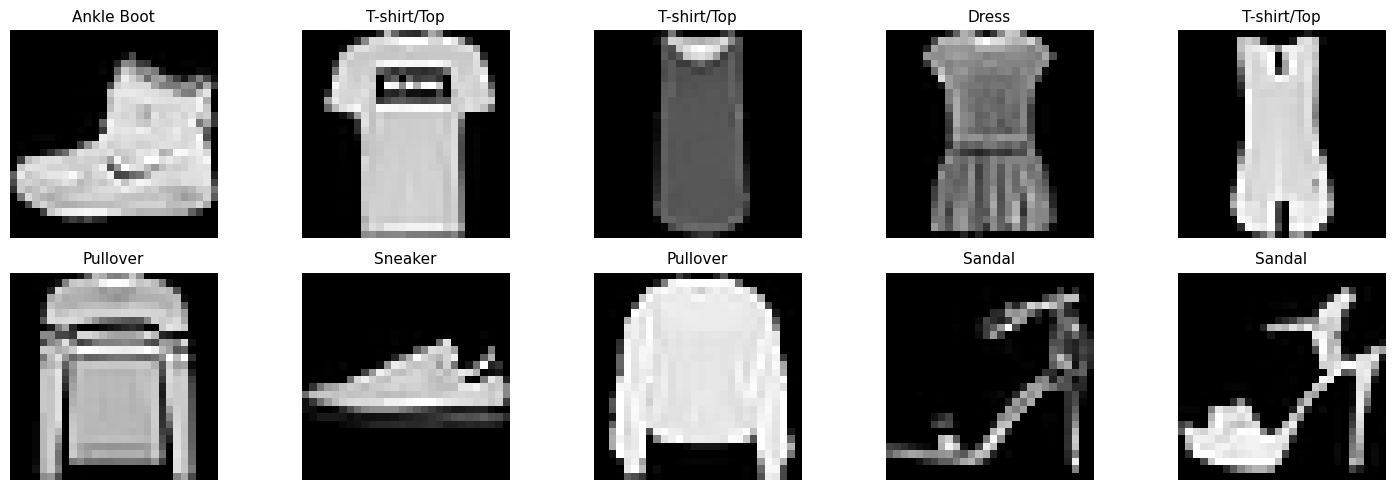

In [68]:
# Display sample images
plt.figure(figsize=(15,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=11)
    plt.axis("off")
plt.tight_layout()
plt.savefig("plots/sample_images.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

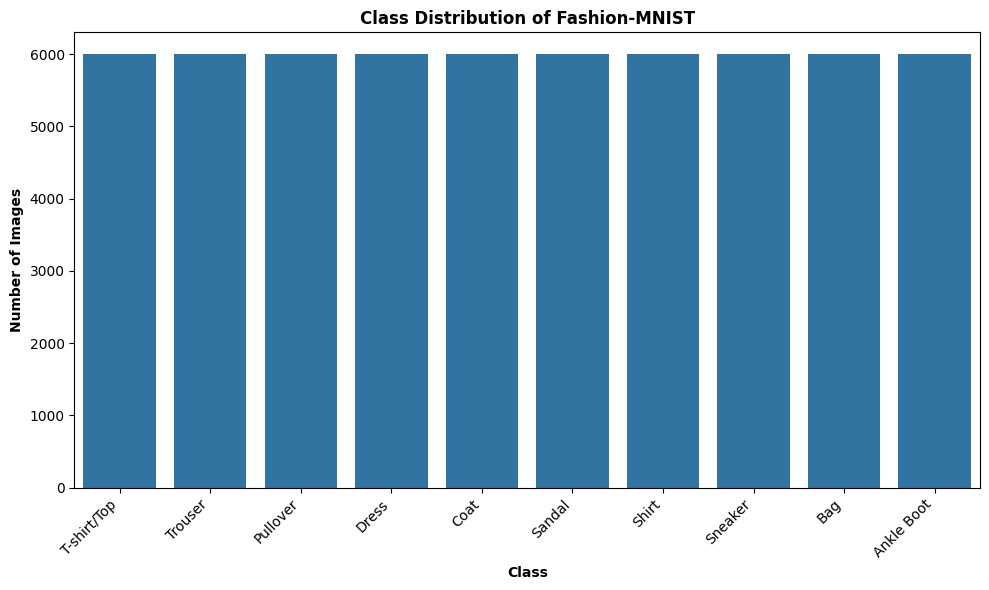

In [69]:
# Class Distribution
plt.figure(figsize=(10,6))
sns.countplot(x=y_train)
plt.title("Class Distribution of Fashion-MNIST", fontweight="bold")
plt.xlabel("Class", fontweight="bold")
plt.ylabel("Number of Images", fontweight="bold")
plt.xticks(
    ticks=range(10),
    labels=class_names,
    rotation=45,
    ha="right"
)
plt.tight_layout()
plt.savefig("plots/class_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**TASK-2**

In [57]:
print("="*50)
print("Before Preprocessing")
print("="*50)
print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", x_test.shape)
print("Testing Labels  :", y_test.shape)

Before Preprocessing
Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


In [58]:
# Flatten images
x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)

In [59]:
x_train_flat = x_train_flat.astype("float32") / 255.0
x_test_flat = x_test_flat.astype("float32") / 255.0

In [60]:
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [61]:
print("="*50)
print("After Preprocessing")
print("="*50)
print("Training Images :", x_train_flat.shape)
print("Training Labels :", y_train_cat.shape)
print("Testing Images  :", x_test_flat.shape)
print("Testing Labels  :", y_test_cat.shape)

After Preprocessing
Training Images : (60000, 784)
Training Labels : (60000, 10)
Testing Images  : (10000, 784)
Testing Labels  : (10000, 10)


In [62]:
print("Minimum Pixel Value :", x_train_flat.min())
print("Maximum Pixel Value :", x_train_flat.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


In [63]:
print("Original Label      :", y_train[0])
print("One-Hot Encoded     :", y_train_cat[0])

Original Label      : 9
One-Hot Encoded     : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


**TASK-3**

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [16]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**TASK-4**

In [18]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
history = model.fit(
    x_train_flat,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8175 - loss: 0.5121 - val_accuracy: 0.8475 - val_loss: 0.4200
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8596 - loss: 0.3786 - val_accuracy: 0.8627 - val_loss: 0.3840
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8742 - loss: 0.3405 - val_accuracy: 0.8707 - val_loss: 0.3709
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8818 - loss: 0.3181 - val_accuracy: 0.8783 - val_loss: 0.3397
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8887 - loss: 0.2992 - val_accuracy: 0.8832 - val_loss: 0.3300
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8943 - loss: 0.2847 - val_accuracy: 0.8825 - val_loss: 0.3242
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9007 - loss: 0.2678 - val_accuracy: 0.8751 - val_loss: 0.3517
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9019 - loss: 0.2597 - 

In [20]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [21]:
print(f"Final Training Accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}")

Final Training Accuracy   : 0.9346
Final Validation Accuracy : 0.8914


In [22]:
print(f"Final Training Loss   : {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss : {history.history['val_loss'][-1]:.4f}")

Final Training Loss   : 0.1753
Final Validation Loss : 0.3545


**TASK-5**

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [64]:
y_pred_prob = model.predict(x_test_flat)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [65]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")
print("="*50)
print("Model Evaluation")
print("="*50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Model Evaluation
Accuracy : 0.8862
Precision: 0.8867
Recall   : 0.8862
F1 Score : 0.8856


In [66]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[857   7  20  19   4   0  86   0   7   0]
 [  0 975   2  13   6   0   2   0   1   1]
 [ 15   1 780  12 129   0  63   0   0   0]
 [ 24  15  11 885  39   1  23   0   2   0]
 [  1   1  72  24 873   0  28   0   1   0]
 [  0   0   0   0   0 968   0  18   1  13]
 [126   4  75  31  93   0 662   0   9   0]
 [  0   0   0   0   0  16   0 974   0  10]
 [  6   0   6   2   7  14   6   8 951   0]
 [  0   0   0   0   0   7   1  55   0 937]]


In [67]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/Top       0.83      0.86      0.84      1000
     Trouser       0.97      0.97      0.97      1000
    Pullover       0.81      0.78      0.79      1000
       Dress       0.90      0.89      0.89      1000
        Coat       0.76      0.87      0.81      1000
      Sandal       0.96      0.97      0.97      1000
       Shirt       0.76      0.66      0.71      1000
     Sneaker       0.92      0.97      0.95      1000
         Bag       0.98      0.95      0.96      1000
  Ankle Boot       0.98      0.94      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



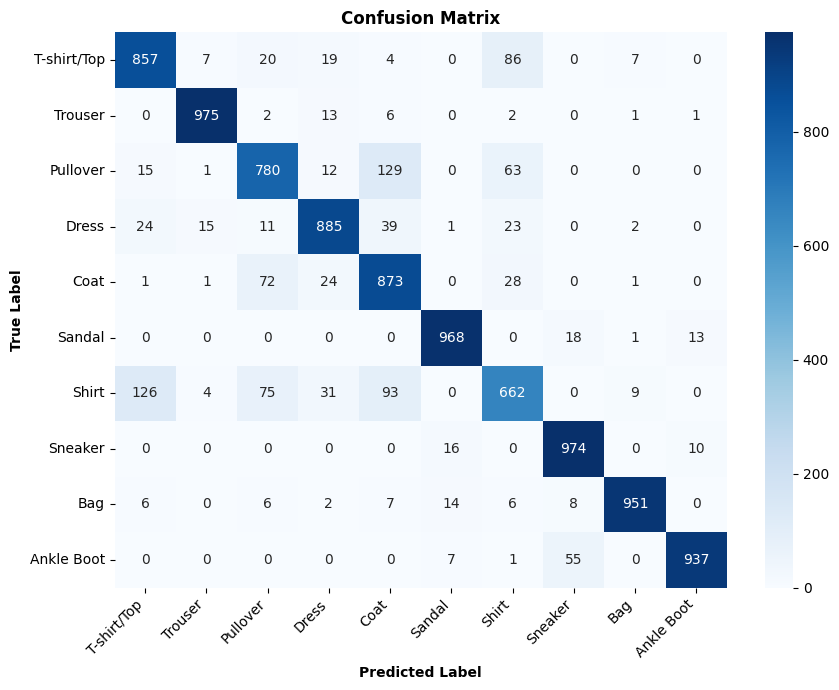

In [28]:
plt.figure(figsize=(9,7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted Label", fontweight="bold")
plt.ylabel("True Label", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("plots/confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Hyperparameter Optimization**

In [29]:
!pip install -U scikeras scikit-learn

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

In [31]:
def create_model(hidden1=128, hidden2=64, optimizer="adam"):
    model = Sequential([
        Dense(hidden1, activation="relu", input_shape=(784,)),
        Dense(hidden2, activation="relu"),
        Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [32]:
model_cv = KerasClassifier(
    model=create_model,
    verbose=0
)

In [33]:
param_dist = {
    "model__hidden1": [64, 128, 256],
    "model__hidden2": [32, 64, 128],
    "optimizer": ["adam", "rmsprop"],
    "batch_size": [32, 64],
    "epochs": [10, 15, 20]
}

In [34]:
random_search = RandomizedSearchCV(
    estimator=model_cv,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

In [35]:
random_search.fit(
    x_train_flat,
    y_train_cat
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasClassifi..._weight=None )
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'batch_size': [32, 64], 'epochs': [10, 15, ...], 'model__hidden1': [64, 128, ...], 'model__hidden2': [32, 64, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple 

In [36]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'optimizer': 'rmsprop', 'model__hidden2': 128, 'model__hidden1': 128, 'epochs': 15, 'batch_size': 64}


In [37]:
print("Best Cross Validation Accuracy:")
print(random_search.best_score_)

Best Cross Validation Accuracy:
0.8873666666666667


In [38]:
best_model = random_search.best_estimator_

In [39]:
best_accuracy = best_model.score(x_test_flat, y_test_cat)
print(f"Optimized Test Accuracy : {best_accuracy:.4f}")

Optimized Test Accuracy : 0.8876


In [40]:
import pandas as pd
results = pd.DataFrame(random_search.cv_results_)
results[[
    "mean_test_score",
    "param_model__hidden1",
    "param_model__hidden2",
    "param_optimizer",
    "param_batch_size",
    "param_epochs"
]].sort_values(by="mean_test_score", ascending=False)

,mean_test_score,param_model__hidden1,param_model__hidden2,param_optimizer,param_batch_size,param_epochs
3,0.887367,128,128,rmsprop,64,15
2,0.885017,64,128,adam,32,10
0,0.883483,64,128,rmsprop,64,15
1,0.880700,128,128,adam,32,10
4,0.877017,128,64,adam,64,10


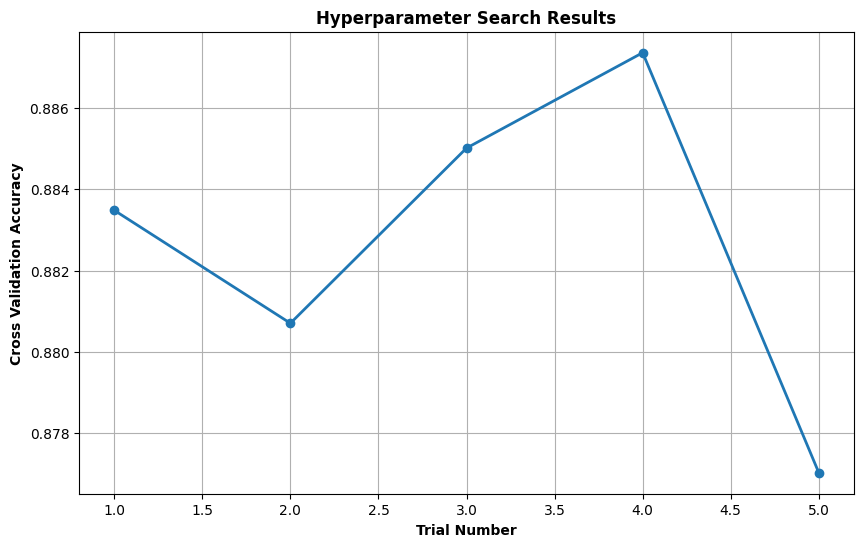

In [70]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(results)+1),
    results["mean_test_score"],
    marker="o",
    linewidth=2
)
plt.title("Hyperparameter Search Results", fontweight="bold")
plt.xlabel("Trial Number", fontweight="bold")
plt.ylabel("Cross Validation Accuracy", fontweight="bold")
plt.grid(True)
plt.savefig("plots/hyperparameter_search_results.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

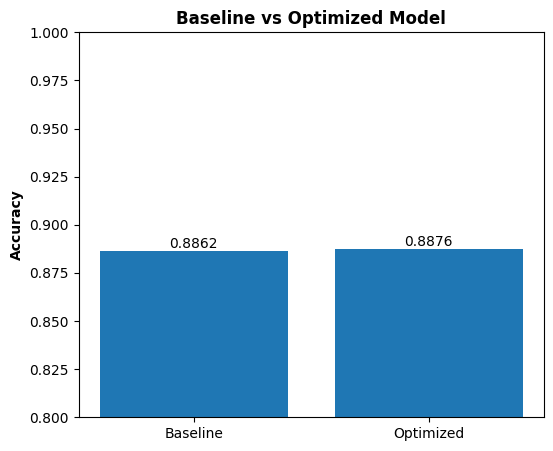

In [71]:
models = ["Baseline", "Optimized"]
accuracies = [accuracy, best_accuracy]
plt.figure(figsize=(6,5))
bars = plt.bar(models, accuracies)
plt.ylabel("Accuracy", fontweight="bold")
plt.title("Baseline vs Optimized Model", fontweight="bold")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )
plt.ylim(0.80,1.0)
plt.savefig("plots/Model_Accuracy_Comparison.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

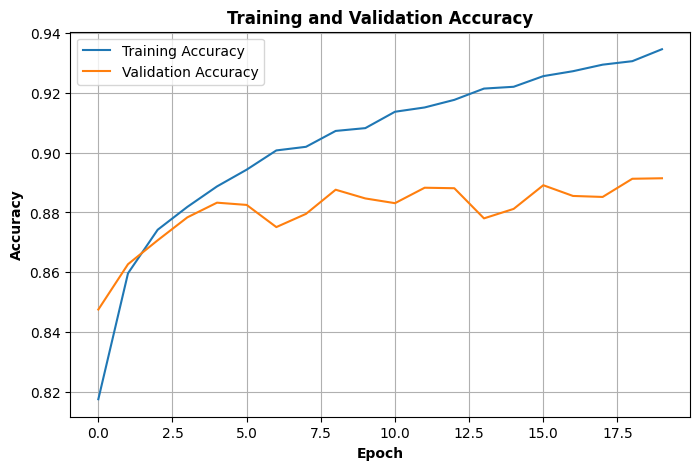

In [73]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy", fontweight="bold")
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Accuracy", fontweight="bold")
plt.legend()
plt.grid(True)
plt.savefig("plots/Training_and_Validation_Accuracy.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

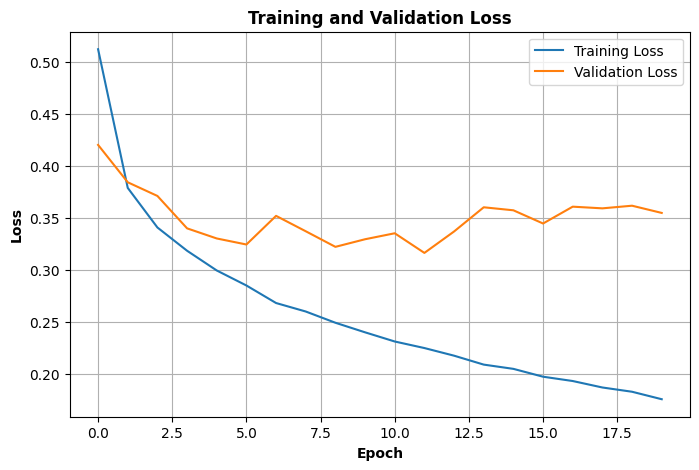

In [74]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss", fontweight="bold")
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Loss", fontweight="bold")
plt.legend()
plt.grid(True)
plt.savefig("plots/Training_and_Validation_Loss.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [75]:
import shutil
shutil.make_archive("plots", "zip", "plots")

'/content/plots.zip'

In [76]:
from google.colab import files
files.download("plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>